# N1 · 端到端 mini-VLM 流水线 (End-to-End mini-VLM)

> 配套 10.7-L1 · 用 `mm_capstone` 检查 M10 装配, 然后真跑一条端到端流水线 (复用 10.1-10.4 的 src):
> 图 → 视觉塔 → 连接器 → tiny LLM → 理解; 再 VQ → 自回归 → 画图。M10 全线跑通一次。

In [1]:
import sys
from pathlib import Path
LR = Path.cwd().parent.parent   # learning/
for t in ["multimodal-graduation","vision-encoders","vl-fusion-architectures",
          "vlm-training-recipe","visual-tokenization-generation"]:
    sys.path.insert(0, str(LR / t / "src"))
import numpy as np, torch
import mm_capstone as mc
print('就绪 (跨专题复用 M10 src)')

就绪 (跨专题复用 M10 src)


## 1. 装配检查: M10 六块都在吗? (L1)

In [2]:
root = Path.cwd().parent.parent
for s in mc.assemble_pipeline_check(root):
    print(f"  {'✅' if s['就位'] else '❌'} {s['专题']:32} {s['作用']}")
print("\n→ 六块咬合成一条能力链 (每块 src 被下游复用)。")

  ✅ vision-encoders                  视觉塔 (ViT/CLIP/SigLIP)
  ✅ vl-fusion-architectures          VL 连接器 (投影/cross-attn/early)
  ✅ vlm-training-recipe              VLM 训练 (两阶段配方)
  ✅ visual-tokenization-generation   视觉 token 化 (VQ, 让画图)
  ✅ video-audio-omni                 时序模态 (视频/音频)
  ✅ vlm-eval-hallucination           VLM 评测 (POPE 幻觉)

→ 六块咬合成一条能力链 (每块 src 被下游复用)。


## 2. 理解侧: 图 → 视觉塔(10.1) → 连接器(10.2) → tiny LLM(10.3) → 答案

In [3]:
import tiny_vit as tv, connectors as cn, torch.nn as nn
torch.manual_seed(0)
img = tv.make_synthetic_image('blocks', size=16, seed=3)
patches = tv.patchify(img, patch=4)
vit = tv.build_tiny_vit(patch_dim=patches.shape[1], n_patches=16, d_model=32)
vis_tok = vit(torch.tensor(patches[None], dtype=torch.float32))[:, 1:]      # 10.1
proj = cn.build_connectors(vis_dim=32, llm_dim=48, n_vis=16)['projection']  # 10.2
txt = nn.Embedding(50, 48)(torch.tensor([[5,12,7]]))
fused = proj(vis_tok, txt)                                                   # 拼接
llm = nn.TransformerEncoder(nn.TransformerEncoderLayer(48,4,96,batch_first=True),2)  # 10.3
out = llm(fused)
print(f"理解流水线: 图{img.shape} → 视觉token{tuple(vis_tok.shape)} → 融合{tuple(fused.shape)} → LLM输出{tuple(out.shape)}")
print("→ 图被读进 LLM, 视觉和文本在统一自注意力里互相 attend (完整 VLM 理解链)。")

理解流水线: 图(16, 16, 3) → 视觉token(1, 16, 32) → 融合(1, 19, 48) → LLM输出(1, 19, 48)
→ 图被读进 LLM, 视觉和文本在统一自注意力里互相 attend (完整 VLM 理解链)。


## 3. 生成侧: 图 → VQ 离散 token(10.4) → (可自回归生成新图)

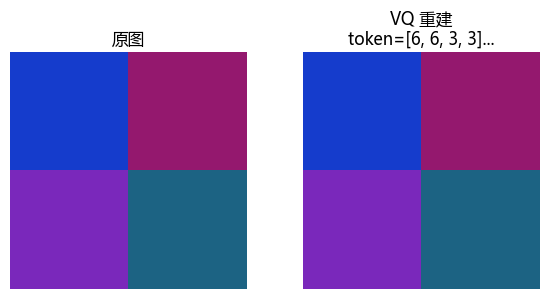

生成侧: 图 → 16 个离散视觉 token (可自回归生成 = 画图, 10.4)


In [4]:
import matplotlib, matplotlib.pyplot as plt
matplotlib.rcParams['axes.unicode_minus']=False
for f in ['Microsoft YaHei','SimHei','DejaVu Sans']:
    try: matplotlib.rcParams['font.sans-serif']=[f]; break
    except Exception: pass
import vq_tokenizer as vq
recon, tokens, mse = vq.reconstruct(img, codebook_size=16, patch=4, seed=1)
fig, ax = plt.subplots(1,2, figsize=(6,3))
ax[0].imshow(np.clip(img,0,1)); ax[0].set_title('原图'); ax[0].axis('off')
ax[1].imshow(np.clip(recon,0,1)); ax[1].set_title(f'VQ 重建\ntoken={tokens.tolist()[:4]}...'); ax[1].axis('off')
plt.tight_layout(); plt.show()
print(f"生成侧: 图 → {len(tokens)} 个离散视觉 token (可自回归生成 = 画图, 10.4)")

## 4. 反思
你把 M10 全线 (视觉塔→连接器→LLM→理解 + VQ→生成) 端到端跑通了一次。带走:
- 这是一个**机制完整**的 mini-VLM: 能读图、能画图。tiny↔真实只换规模/预训练。
- M10 给你的 48 工程专题装上了眼睛和嘴。
下一步 N2: 把这套能力变成 PhD 研究 —— 用 9.3 gap 雷达起一张 VLM 研究 idea 卡。